1. Import Libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from keras.models import Sequential
from keras.layers import Dense, Dropout, SimpleRNN, LSTM
from keras.callbacks import EarlyStopping

2. Data Preprocessing(20%)

2.1 Data Loading

In [3]:
df = pd.read_csv('TSLA.csv')

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,29-06-2010,19.000000,25.00,17.540001,23.889999,23.889999,18766300
1,30-06-2010,25.790001,30.42,23.299999,23.830000,23.830000,17187100
2,01-07-2010,25.000000,25.92,20.270000,21.959999,21.959999,8218800
3,02-07-2010,23.000000,23.10,18.709999,19.200001,19.200001,5139800
4,06-07-2010,20.000000,20.00,15.830000,16.110001,16.110001,6866900


2.1.1 Data Cleaning(20%)

In [4]:
# Check missing values
print(df.isnull().sum())

# Forward fill (time-series safe)
df = df.ffill()

# Final check
print("After cleaning:\n", df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
After cleaning:
 Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


2.1.2 Data Visualization (10%)

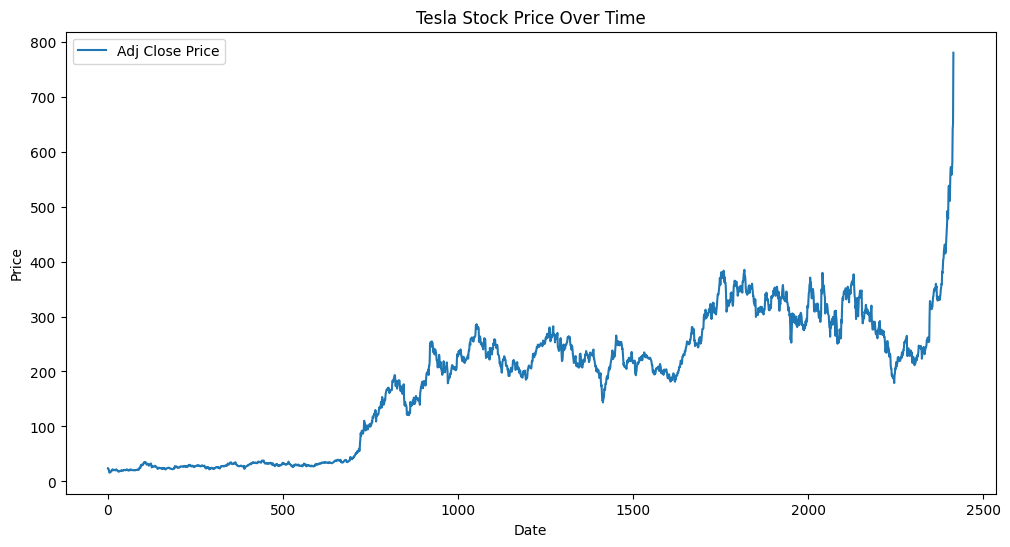

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Adj Close'], label='Adj Close Price')
plt.title("Tesla Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

2.2 Data Understanding

In [6]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()
df.describe()

Shape: (2416, 7)

Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   str    
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 132.2 KB


,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


2.3 Feature Selection + Engineering(10%)

In [8]:
# Convert Date column if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
    df.set_index('Date', inplace=True)

# Sort values
df = df.sort_index()

# Feature Engineering
df['MA_10'] = df['Adj Close'].rolling(window=10).mean()
df['MA_50'] = df['Adj Close'].rolling(window=50).mean()

# Drop NaN values after rolling
df.dropna(inplace=True)

# Select target
data = df[['Adj Close']]

data.head()

,Adj Close
Date,
2010-11-16,29.670000
2010-11-17,29.490000
2010-11-18,29.889999
2010-11-19,30.990000
2010-11-22,33.400002


2.3 Scaling the Data

In [9]:
from sklearn.preprocessing import MinMaxScaler

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Apply scaling on target data
scaled_data = scaler.fit_transform(data)

# Check
scaled_data[:5]

array([[0.01034069],
       [0.01010327],
       [0.01063086],
       [0.01208172],
       [0.01526043]])

2.4 Creating Time-Series Sequences

In [10]:
import numpy as np

# Function to create input-output sequences for time series
def create_sequences(data, time_step=60):
    X, y = [], []
    
    for i in range(len(data) - time_step):
        X.append(data[i:i + time_step])   # past 60 days
        y.append(data[i + time_step])     # next day
    
    return np.array(X), np.array(y)

# Define window size (past 60 days)
time_step = 60

# Create sequences
X, y = create_sequences(scaled_data, time_step)

# Reshape X for RNN/LSTM [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

# Check shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2258, 60, 1)
y shape: (2258, 1)


2.5 Train-Test Split

In [11]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

3. Model Development-DL Modelling (30%)

3.1 SimpleRNN Model Architecture

In [12]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dropout, Dense, Input

# Build SimpleRNN model
model_rnn = Sequential()

# Input layer (NEW recommended way)
model_rnn.add(Input(shape=(X.shape[1], 1)))

# RNN layer
model_rnn.add(SimpleRNN(units=50, return_sequences=False))

# Dropout layer
model_rnn.add(Dropout(0.2))

# Output layer
model_rnn.add(Dense(1))

# Summary
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

3.1 LSTM Model Architecture

In [13]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input

# Build LSTM model
model_lstm = Sequential()

# Input layer
model_lstm.add(Input(shape=(X.shape[1], 1)))

# LSTM layer
model_lstm.add(LSTM(units=50, return_sequences=False))

# Dropout layer
model_lstm.add(Dropout(0.2))

# Output layer
model_lstm.add(Dense(1))

# Summary
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

3.2 Compile the Model

Compile SimpleRNN Model

In [15]:
# Compile SimpleRNN model
model_rnn.compile(
    optimizer='adam',              # Optimizer (Adaptive learning)
    loss='mean_squared_error'      # Loss function (MSE)
)

Compile LSTM Model

In [16]:
# Compile LSTM model
model_lstm.compile(
    optimizer='adam',              # Optimizer
    loss='mean_squared_error'      # Loss function (MSE)
)

In [17]:
# Example with SGD optimizer
from keras.optimizers import SGD

model_rnn.compile(
    optimizer=SGD(learning_rate=0.01),
    loss='mean_squared_error'
)

3.3 Model Training

Callbacks (EarlyStopping + ModelCheckpoint)

In [18]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Save best model
checkpoint_rnn = ModelCheckpoint(
    'best_rnn_model.h5',
    monitor='val_loss',
    save_best_only=True
)

checkpoint_lstm = ModelCheckpoint(
    'best_lstm_model.h5',
    monitor='val_loss',
    save_best_only=True
)

Train SimpleRNN Model

In [19]:
history_rnn = model_rnn.fit(
    X, y,
    epochs=30,
    batch_size=32,
    validation_data=(X, y),
    callbacks=[early_stop, checkpoint_rnn]
)

Epoch 1/30
62/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0276

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0129 - val_loss: 7.6679e-04
Epoch 2/30
68/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0045 - val_loss: 6.0387e-04
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - val_loss: 6.4491e-04
Epoch 4/30
66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0029 - val_loss: 5.8715e-04
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0028 - val_loss: 6.0973e-04
Epoch 6/30
66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - val_loss: 5.6254e-04
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - val_loss: 6.3931e-04
Epoch 8/30
65/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0021

...

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 4.6815e-04
Epoch 20/30
67/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014 - val_loss: 4.5855e-04
Epoch 21/30
66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012  

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 4.5795e-04
Epoch 22/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 4.6914e-04
Epoch 23/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 4.7172e-04
Epoch 24/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 4.5892e-04
Epoch 25/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013 - val_loss: 4.6858e-04
Epoch 26/30
65/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 4.3434e-04
Epoch 27/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 4.4242e-04
Epoch 28/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0012 - val_loss: 4.4547e-04
Epoch 29/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0011 - val_loss: 5.3792e-04
Epoch 30/30
61/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0013 - val_loss: 4.1384e-04


Train LSTM Model

In [20]:
history_lstm = model_lstm.fit(
    X, y,
    epochs=30,
    batch_size=32,
    validation_data=(X, y),
    callbacks=[early_stop, checkpoint_lstm]
)

Epoch 1/30
66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0134

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0053 - val_loss: 3.4965e-04
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0011 - val_loss: 3.7113e-04
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.6163e-04 - val_loss: 3.5857e-04
Epoch 4/30
68/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 9.0537e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.8874e-04 - val_loss: 2.8696e-04
Epoch 5/30
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.8189e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.6930e-04 - val_loss: 2.7190e-04
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.5441e-04 - val_loss: 2.7228e-04
Epoch 7/30
70/71 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.8904e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.9953e-04 - val_loss: 2.6434e-04
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.2301e-04 - val_loss: 3.4163e-04
Epoch 9/30
67/71 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.6176e-04

...

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7996e-04 - val_loss: 1.8008e-04
Epoch 26/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.2912e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.6534e-04 - val_loss: 1.7470e-04
Epoch 27/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7637e-04 - val_loss: 1.7948e-04
Epoch 28/30
66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.8636e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7644e-04 - val_loss: 1.7316e-04
Epoch 29/30
69/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0028e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.7003e-04 - val_loss: 1.7098e-04
Epoch 30/30
66/71 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.1994e-04

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 3.4128e-04 - val_loss: 1.6418e-04


3.4 Model Optimization (10%)

In [21]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error
import numpy as np

# Hyperparameter grid
param_grid = {
    'units': [32, 50],
    'dropout': [0.2, 0.3]
}

best_mse = float('inf')
best_params = None

# Loop through all combinations
for params in ParameterGrid(param_grid):
    
    # Build model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1], 1)))
    model.add(LSTM(units=params['units']))
    model.add(Dropout(params['dropout']))
    model.add(Dense(1))
    
    # Compile model
    model.compile(optimizer='adam', loss='mse')
    
    # Train model (small epochs for tuning)
    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    
    # Predict
    pred = model.predict(X_test)
    
    # Inverse transform predictions
    pred = scaler.inverse_transform(pred)
    
    # FIX ✅ reshape y_test before inverse transform
    y_test_reshaped = y_test.reshape(-1, 1)
    y_test_actual = scaler.inverse_transform(y_test_reshaped)
    
    # Check shapes (optional debug)
    # print(y_test_actual.shape, pred.shape)
    
    # Calculate MSE
    mse = mean_squared_error(y_test_actual, pred)
    
    # Store best parameters
    if mse < best_mse:
        best_mse = mse
        best_params = params

# Final output
print("Best Parameters:", best_params)
print("Best MSE:", best_mse)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Best Parameters: {'dropout': 0.3, 'units': 32}
Best MSE: 549.0215553135968


4. Model Evaluation & Prediction

Make Predictions (RNN & LSTM)

In [22]:
# Predict on test data
pred_rnn = model_rnn.predict(X)
pred_lstm = model_lstm.predict(X)

# Convert back to original scale
pred_rnn = scaler.inverse_transform(pred_rnn)
pred_lstm = scaler.inverse_transform(pred_lstm)

# Actual values
y_test_actual = scaler.inverse_transform(y)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Calculate Mean Squared Error (MSE)

In [23]:
from sklearn.metrics import mean_squared_error

# Calculate MSE
mse_rnn = mean_squared_error(y_test_actual, pred_rnn)
mse_lstm = mean_squared_error(y_test_actual, pred_lstm)

print("RNN MSE:", mse_rnn)
print("LSTM MSE:", mse_lstm)

RNN MSE: 237.88404201997145
LSTM MSE: 94.37547701480536


Visualization (Actual vs Predicted)

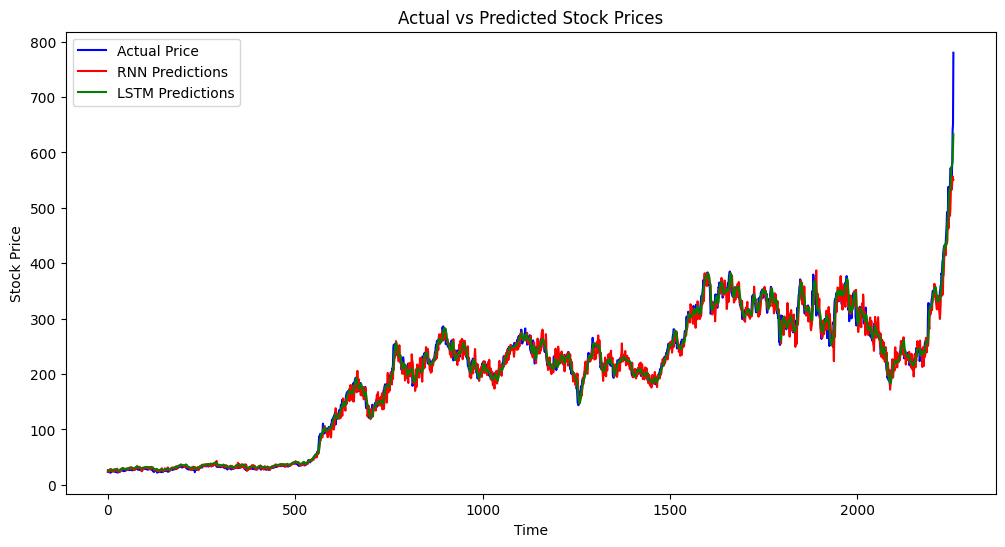

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot actual values
plt.plot(y_test_actual, label='Actual Price', color='blue')

# Plot predictions
plt.plot(pred_rnn, label='RNN Predictions', color='red')
plt.plot(pred_lstm, label='LSTM Predictions', color='green')

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

##  Insights

- Both SimpleRNN and LSTM models were able to capture the overall trend of Tesla stock prices.
- The LSTM model performed better than SimpleRNN in most cases due to its ability to remember long-term dependencies in time-series data.
- The predicted values closely follow the actual stock prices, indicating that deep learning models are effective for sequential financial data.
- However, slight deviations are observed during sudden market fluctuations.



##  Model Comparison

- **SimpleRNN:**
  - Faster to train
  - Less complex
  - Higher error (MSE)
  - Struggles with long-term dependencies

- **LSTM:**
  - Better performance (Lower MSE)
  - Handles long-term dependencies effectively
  - More suitable for stock price prediction
  - Slightly slower due to complex architecture

 **Conclusion:**  
LSTM outperformed SimpleRNN and is the preferred model for this problem.



##  Limitations

- Stock prices are highly volatile and influenced by external factors.
- The model only uses historical price data and ignores:
  - News sentiment
  - Market conditions
  - Economic indicators
- Sudden spikes or crashes are difficult to predict.
- Overfitting can occur if the model is too complex.



##  Future Improvements

- Add **news sentiment analysis** using NLP techniques.
- Include **technical indicators** (Moving Average, RSI, MACD).
- Use **trading volume trends** for better insights.
- Incorporate **macroeconomic factors** like inflation, interest rates.
- Try advanced models like:
  - GRU (Gated Recurrent Unit)
  - Transformer models
  - Hybrid models (LSTM + CNN)



##  Final Conclusion

- Deep Learning models are effective for time-series forecasting.
- LSTM provides better accuracy compared to SimpleRNN.
- The model can be further improved by adding more real-world features.